# 1. Does late delivery cost repeat business?

**Question:** customers whose first order arrived late, do they come back less often than customers whose first order arrived on time?

**Definitions**
- *first order*: a customer's earliest order (by `customer_unique_id`), only if it was delivered.
- *late*: delivered after the estimated delivery date shown to the customer.
- *repeat*: the customer placed another order **after** the first one was delivered and within **180 days** of that delivery. Orders placed before the first one arrived don't count, because the customer couldn't have known it would be late yet.
- To give everyone the same 180-day window, I only keep first orders delivered at least 180 days before the last purchase in the data.

In [1]:
import pathlib
import sys

sys.path.insert(0, str(pathlib.Path.cwd().parent))  # repo root, for `analysis` and `common`

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf

from analysis.stats import compare_proportions
from common.db import query

pd.set_option("display.float_format", "{:.4f}".format)
WINDOW_DAYS = 180

In [2]:
firsts = query("""
with last_purchase as (
    select max(purchased_at) as ts from marts.fct_orders
),
firsts as (
    select o.*
    from marts.fct_orders o, last_purchase lp
    where o.customer_order_number = 1
      and o.is_delivered
      and o.delivered_at <= lp.ts - make_interval(days => :window)
),
first_category as (
    select order_id, category
    from marts.fct_order_items
    where order_item_id = 1
)
select
    f.customer_unique_id,
    f.order_id,
    f.customer_state,
    fc.category,
    f.order_total,
    f.delay_days,
    f.is_late,
    exists (
        select 1 from marts.fct_orders o2
        where o2.customer_unique_id = f.customer_unique_id
          and o2.purchased_at > f.delivered_at
          and o2.purchased_at <= f.delivered_at + make_interval(days => :window)
    ) as repeated
from firsts f
left join first_category fc using (order_id)
""", window=WINDOW_DAYS)

print(f"{len(firsts):,} first orders in the analysis window")
firsts.groupby("is_late")["repeated"].agg(["count", "sum", "mean"])

63,681 first orders in the analysis window


,count,sum,mean
is_late,,,
False,59167,1063,0.0180
True,4514,55,0.0122


## Test: two-proportion z test

H0: the repeat rate is the same for late and on-time first orders. Two-sided, alpha = 0.05.

In [3]:
g = firsts.groupby("is_late")["repeated"].agg(["sum", "count"])
res = compare_proportions(
    success_a=int(g.loc[True, "sum"]), n_a=int(g.loc[True, "count"]),
    success_b=int(g.loc[False, "sum"]), n_b=int(g.loc[False, "count"]),
)

print(f"late first order:    {res.rate_a:.2%} repeat  (n={res.n_a:,})")
print(f"on-time first order: {res.rate_b:.2%} repeat  (n={res.n_b:,})")
print(f"difference:          {res.diff * 100:+.2f} pp  95% CI [{res.ci_low * 100:+.2f}, {res.ci_high * 100:+.2f}]")
print(f"z = {res.z:.2f}, p = {res.p_value:.4f}")
print(f"relative risk = {res.relative_risk:.2f}, Cohen's h = {res.cohens_h:.3f}")

late first order:    1.22% repeat  (n=4,514)
on-time first order: 1.80% repeat  (n=59,167)
difference:          -0.58 pp  95% CI [-0.92, -0.24]
z = -2.85, p = 0.0044
relative risk = 0.68, Cohen's h = -0.048


Cohen's h is the effect size for a difference between two proportions (0.2 is usually called small). When the base rate is only a few percent, h looks tiny even when the relative change is large, so I report the relative risk too.

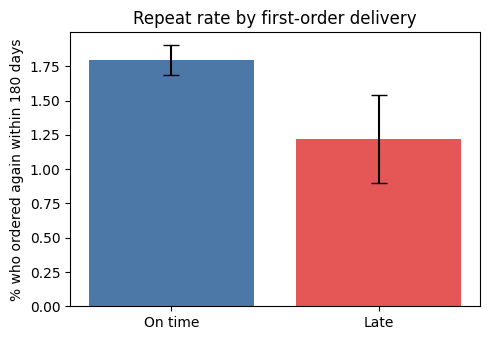

In [4]:
fig, ax = plt.subplots(figsize=(5, 3.5))
labels = ["On time", "Late"]
rates = [res.rate_b, res.rate_a]
ns = [res.n_b, res.n_a]
errs = [1.96 * np.sqrt(r * (1 - r) / n) for r, n in zip(rates, ns)]
ax.bar(labels, [r * 100 for r in rates], yerr=[e * 100 for e in errs], capsize=6,
       color=["#4C78A8", "#E45756"])
ax.set_ylabel(f"% who ordered again within {WINDOW_DAYS} days")
ax.set_title("Repeat rate by first-order delivery")
plt.tight_layout()
plt.show()

## Does it hold after accounting for obvious confounders?

Late orders are not random. They cluster in some states (distance from the sellers in São Paulo) and some categories (bulky items). A logistic regression with state, category and order value as controls checks whether the gap survives. This is still observational: it can only adjust for what is measured.

In [5]:
top_states = firsts["customer_state"].value_counts().index[:10]
top_cats = firsts["category"].value_counts().index[:15]
model_df = firsts.assign(
    repeated=firsts["repeated"].astype(int),
    late=firsts["is_late"].astype(int),
    state=np.where(firsts["customer_state"].isin(top_states), firsts["customer_state"], "other"),
    cat=np.where(firsts["category"].isin(top_cats), firsts["category"], "other"),
    log_total=np.log1p(firsts["order_total"].astype(float)),
)

logit = smf.logit("repeated ~ late + C(state) + C(cat) + log_total", data=model_df).fit(disp=False)
or_late = np.exp(logit.params["late"])
or_ci = np.exp(logit.conf_int().loc["late"])
print(f"odds ratio for a late first order: {or_late:.2f}  95% CI [{or_ci[0]:.2f}, {or_ci[1]:.2f}]  p = {logit.pvalues['late']:.4f}")

odds ratio for a late first order: 0.69  95% CI [0.53, 0.91]  p = 0.0094


## Does how late matter?

In [6]:
late_bins = pd.cut(
    firsts["delay_days"].astype(float),
    bins=[-np.inf, 0, 3, 7, 14, np.inf],
    labels=["on time", "1-3 days late", "4-7 days late", "8-14 days late", "15+ days late"],
)
firsts.groupby(late_bins, observed=True)["repeated"].agg(["count", "mean"])

,count,mean
delay_days,,
on time,59167,0.0180
1-3 days late,1267,0.0150
4-7 days late,1269,0.0110
8-14 days late,1043,0.0125
15+ days late,935,0.0096


## Limitations
- **Observational.** Late deliveries are more common for some regions, sellers and product types, and those may have their own repeat rates. The regression adjusts for state, category and order value, but not for seller, price sensitivity, or anything we can't see.
- **Repeat purchase is rare in this marketplace**, so the absolute numbers are small and the interval is wide relative to the base rate.
- Olist is a marketplace: a customer who comes back may buy from a different seller, so this measures loyalty to the platform, not to a store.

## What this means for the business

Customers whose first order arrived late came back less often: **1.22% vs 1.80%** within 180 days. That is 0.58 percentage points lower (95% CI 0.24 to 0.92) and about a third fewer repeat buyers (relative risk 0.68). The gap holds after controlling for state, category and order value (odds ratio 0.69, 95% CI 0.53 to 0.91), and repeat rates are generally lower the later the order arrived.

Repeat buying is rare on this marketplace, so the absolute loss is small per customer. It is a cheap signal to act on, though: flag late first orders and try a recovery step (an apology voucher, or more realistic delivery estimates). Because this is observational, that step should be rolled out as an A/B test before anyone claims it caused the difference.